<a href="https://colab.research.google.com/github/Krisha-05-2004/Crime-Analysis-System/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
=============================================================
 CRIME CLASSIFICATION — SAI KRISHA K PART (CU23BCA0048A)
 BCA ML Mini Project: Crime Analysis and Prediction
=============================================================
 Dataset   : cleaned_dataset.csv  (from Ashwanth's preprocessing)
 Target    : Crime_Class  (0 = Low Crime, 1 = High Crime)
 Threshold : 159 total crimes
 Train     : 87 rows  |  Test : 58 rows

 WHAT THIS FILE COVERS:
   Phase 1 — Baseline Validation
   Phase 2 — Logistic Regression, KNN, Decision Tree
   Phase 3 — Confusion Matrix, Threshold Tuning
   Phase 4 — Backtesting, NCRB External Validation
=============================================================
"""

In [ ]:
# ── Standard imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn imports ───────────────────────────────────────────
from sklearn.dummy          import DummyClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.tree           import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold)
from sklearn.metrics        import (accuracy_score, f1_score,
                                    classification_report,
                                    confusion_matrix,
                                    ConfusionMatrixDisplay,
                                    precision_score, recall_score,
                                    precision_recall_curve)

In [ ]:
# 0.  LOAD DATA

from google.colab import files
uploaded = files.upload()

print("=" * 60)
print("  LOADING DATA")
print("=" * 60)

df = pd.read_csv('cleaned_dataset.csv')

print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {list(df.columns)}")
print(f"\nClass distribution:")
print(df['Crime_Class'].value_counts())
print(f"Majority class %: {df['Crime_Class'].value_counts(normalize=True).max():.1%}")

Saving cleaned_dataset.csv to cleaned_dataset.csv
  LOADING DATA
Dataset shape  : (145, 28)
Columns        : ['City', 'Year', 'ARSON', 'ASSAULT', 'BURGLARY', 'COUNTERFEITING', 'CYBERCRIME', 'DOMESTIC VIOLENCE', 'DRUG OFFENSE', 'EXTORTION', 'FIREARM OFFENSE', 'FRAUD', 'HOMICIDE', 'IDENTITY THEFT', 'ILLEGAL POSSESSION', 'KIDNAPPING', 'PUBLIC INTOXICATION', 'ROBBERY', 'SEXUAL ASSAULT', 'SHOPLIFTING', 'TRAFFIC VIOLATION', 'VANDALISM', 'VEHICLE - STOLEN', 'Total_Crimes', 'Population_Lakhs', 'Crime_Rate_Per_Lakh', 'City_Encoded', 'Crime_Class']

Class distribution:
Crime_Class
0    73
1    72
Name: count, dtype: int64
Majority class %: 50.3%


In [ ]:
# ── Identify feature columns ──────────────────────────────────
# Drop non-numeric/identifier columns — adjust if your CSV differs
drop_cols = ['Crime_Class', 'State', 'Year', 'City'] # Added 'City' to drop_cols
# Also drop Crime_Rate_Per_Lakh if present (derived from target — leakage risk)
if 'Crime_Rate_Per_Lakh' in df.columns:
    drop_cols.append('Crime_Rate_Per_Lakh')

feature_cols = [c for c in df.columns if c not in drop_cols]
print(f"\nFeature columns ({len(feature_cols)}): {feature_cols}")

X = df[feature_cols]
y = df['Crime_Class']

# ── Train / Test split (stratified, same seed as Ashwanth) ────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print(f"\nTrain size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")

# ── Scale features (for LR and KNN only) ─────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit only on train!
X_test_sc   = scaler.transform(X_test)        # transform test with train params


Feature columns (24): ['ARSON', 'ASSAULT', 'BURGLARY', 'COUNTERFEITING', 'CYBERCRIME', 'DOMESTIC VIOLENCE', 'DRUG OFFENSE', 'EXTORTION', 'FIREARM OFFENSE', 'FRAUD', 'HOMICIDE', 'IDENTITY THEFT', 'ILLEGAL POSSESSION', 'KIDNAPPING', 'PUBLIC INTOXICATION', 'ROBBERY', 'SEXUAL ASSAULT', 'SHOPLIFTING', 'TRAFFIC VIOLATION', 'VANDALISM', 'VEHICLE - STOLEN', 'Total_Crimes', 'Population_Lakhs', 'City_Encoded']

Train size : 87 rows
Test size  : 58 rows


In [ ]:
# PHASE 1 — BASELINE VALIDATION
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PHASE 1: BASELINE VALIDATION")
print("=" * 60)

# 1a. Majority Class Baseline
majority_class    = int(y_train.mode()[0])
y_pred_majority   = [majority_class] * len(y_test)
maj_acc           = accuracy_score(y_test, y_pred_majority)
maj_f1            = f1_score(y_test, y_pred_majority, average='weighted',
                             zero_division=0)

print("\n--- Baseline 1: Always predict majority class ---")
print(f"Majority class  : {majority_class} "
      f"({'High Crime' if majority_class == 1 else 'Low Crime'})")
print(f"Accuracy        : {maj_acc:.3f}")
print(f"F1 Score        : {maj_f1:.3f}")



  PHASE 1: BASELINE VALIDATION

--- Baseline 1: Always predict majority class ---
Majority class  : 0 (Low Crime)
Accuracy        : 0.500
F1 Score        : 0.333


In [ ]:
# 1b. Stratified DummyClassifier (already run — your screenshot shows 0.534)
dummy   = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy  = dummy.predict(X_test)
dum_acc       = accuracy_score(y_test, y_pred_dummy)
dum_f1        = f1_score(y_test, y_pred_dummy, average='weighted',
                         zero_division=0)

print("\n--- Baseline 2: DummyClassifier (Stratified) ---")
print(f"Accuracy        : {dum_acc:.3f}")
print(f"F1 Score        : {dum_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dummy,
      target_names=['Low Crime', 'High Crime']))

print("\n>>> INTERPRETATION:")
print(f"    Our models must beat F1 > {max(maj_f1, dum_f1):.3f} to be meaningful.")
print("    A model at 53% accuracy is as good as flipping a coin.")



--- Baseline 2: DummyClassifier (Stratified) ---
Accuracy        : 0.534
F1 Score        : 0.534

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.53      0.55      0.54        29
  High Crime       0.54      0.52      0.53        29

    accuracy                           0.53        58
   macro avg       0.53      0.53      0.53        58
weighted avg       0.53      0.53      0.53        58


>>> INTERPRETATION:
    Our models must beat F1 > 0.534 to be meaningful.
    A model at 53% accuracy is as good as flipping a coin.


In [ ]:
# PHASE 2 — TRAIN ALL 3 MODELS
# ─────────────────────────────────────────────────────────────

# ── MODEL 1: Logistic Regression ─────────────────────────────
print("\n" + "=" * 60)
print("  PHASE 2 — MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

# 1a: Default (no class balancing)
lr_default = LogisticRegression(random_state=42, max_iter=1000)
lr_default.fit(X_train_sc, y_train)
y_pred_lr_default = lr_default.predict(X_test_sc)

print("\n--- Logistic Regression: Default ---")
print(classification_report(y_test, y_pred_lr_default,
      target_names=['Low Crime', 'High Crime']))

# 1b: Balanced (penalises misclassifying minority class more)
lr_bal = LogisticRegression(class_weight='balanced',
                             random_state=42, max_iter=1000)
lr_bal.fit(X_train_sc, y_train)
y_pred_lr_bal = lr_bal.predict(X_test_sc)

print("\n--- Logistic Regression: class_weight='balanced' ---")
print(classification_report(y_test, y_pred_lr_bal,
      target_names=['Low Crime', 'High Crime']))

# Store LR balanced F1 for final comparison
lr_f1 = f1_score(y_test, y_pred_lr_bal, average='weighted')


  PHASE 2 — MODEL 1: LOGISTIC REGRESSION

--- Logistic Regression: Default ---
              precision    recall  f1-score   support

   Low Crime       0.91      1.00      0.95        29
  High Crime       1.00      0.90      0.95        29

    accuracy                           0.95        58
   macro avg       0.95      0.95      0.95        58
weighted avg       0.95      0.95      0.95        58


--- Logistic Regression: class_weight='balanced' ---
              precision    recall  f1-score   support

   Low Crime       0.91      1.00      0.95        29
  High Crime       1.00      0.90      0.95        29

    accuracy                           0.95        58
   macro avg       0.95      0.95      0.95        58
weighted avg       0.95      0.95      0.95        58



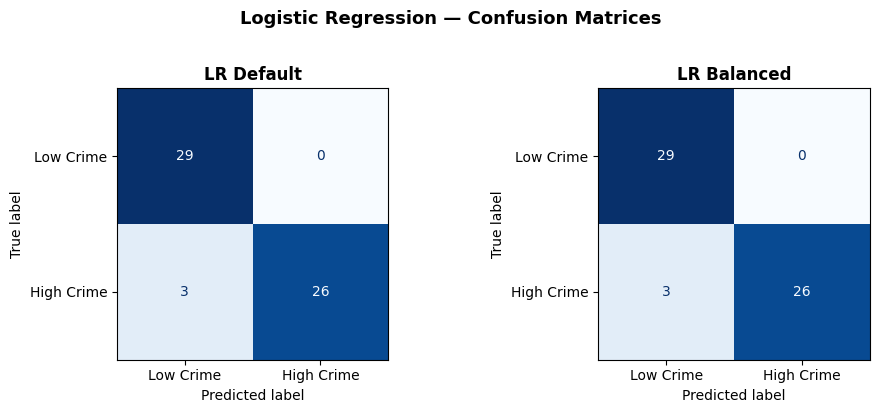

Saved: plot_lr_confusion.png


In [ ]:
# ── Plot: LR Confusion Matrices side by side ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title in zip(
        axes,
        [y_pred_lr_default, y_pred_lr_bal],
        ['LR Default', 'LR Balanced']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Low Crime', 'High Crime'],
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.suptitle('Logistic Regression — Confusion Matrices', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_lr_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_lr_confusion.png")



  PHASE 2 — MODEL 2: KNN (K-Nearest Neighbors)

  K  |  CV F1 Mean  |  CV F1 Std
  ---+-------------+-----------
   3  |   0.9419    |  ±0.0381
   5  |   0.9076    |  ±0.0274
   7  |   0.9068    |  ±0.0293
   9  |   0.9068    |  ±0.0293
  11  |   0.9068    |  ±0.0293
  13  |   0.9068    |  ±0.0293

  >>> Best K = 3  (CV F1 = 0.9419)


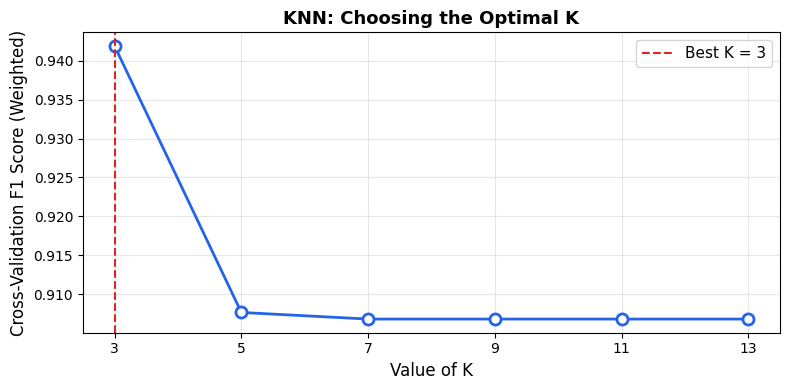

Saved: plot_knn_k_selection.png

--- KNN Final Model (K=3) ---
              precision    recall  f1-score   support

   Low Crime       0.91      1.00      0.95        29
  High Crime       1.00      0.90      0.95        29

    accuracy                           0.95        58
   macro avg       0.95      0.95      0.95        58
weighted avg       0.95      0.95      0.95        58



In [ ]:
# ── MODEL 2: KNN — find optimal K ───────────────────────────
print("\n" + "=" * 60)
print("  PHASE 2 — MODEL 2: KNN (K-Nearest Neighbors)")
print("=" * 60)

k_values    = [3, 5, 7, 9, 11, 13]
cv_f1_list  = []

print("\n  K  |  CV F1 Mean  |  CV F1 Std")
print("  ---+-------------+-----------")
for k in k_values:
    knn    = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train,
                             cv=5, scoring='f1_weighted')
    cv_f1_list.append(scores.mean())
    print(f"  {k:2d}  |   {scores.mean():.4f}    |  ±{scores.std():.4f}")

best_k   = k_values[int(np.argmax(cv_f1_list))]
best_kf1 = max(cv_f1_list)
print(f"\n  >>> Best K = {best_k}  (CV F1 = {best_kf1:.4f})")

# Plot K vs F1
plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_f1_list, marker='o', linewidth=2,
         color='#2563EB', markersize=8, markerfacecolor='white',
         markeredgewidth=2)
plt.axvline(x=best_k, color='#DC2626', linestyle='--',
            label=f'Best K = {best_k}')
plt.xlabel('Value of K', fontsize=12)
plt.ylabel('Cross-Validation F1 Score (Weighted)', fontsize=12)
plt.title('KNN: Choosing the Optimal K', fontsize=13, fontweight='bold')
plt.xticks(k_values)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_knn_k_selection.png', dpi=150)
plt.show()
print("Saved: plot_knn_k_selection.png")

# Final KNN model with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)
y_pred_knn = knn_best.predict(X_test_sc)
knn_f1     = f1_score(y_test, y_pred_knn, average='weighted')

print(f"\n--- KNN Final Model (K={best_k}) ---")
print(classification_report(y_test, y_pred_knn,
      target_names=['Low Crime', 'High Crime']))




  PHASE 2 — MODEL 3: DECISION TREE

  Depth | Train F1 | Val F1 (CV)
  ------+----------+------------
    3   |  1.0000  |  1.0000
    4   |  1.0000  |  1.0000
    5   |  1.0000  |  1.0000
    6   |  1.0000  |  1.0000
    7   |  1.0000  |  1.0000
    8   |  1.0000  |  1.0000
    9   |  1.0000  |  1.0000
    10   |  1.0000  |  1.0000

  >>> Best max_depth = 3  (Val F1 = 1.0000)


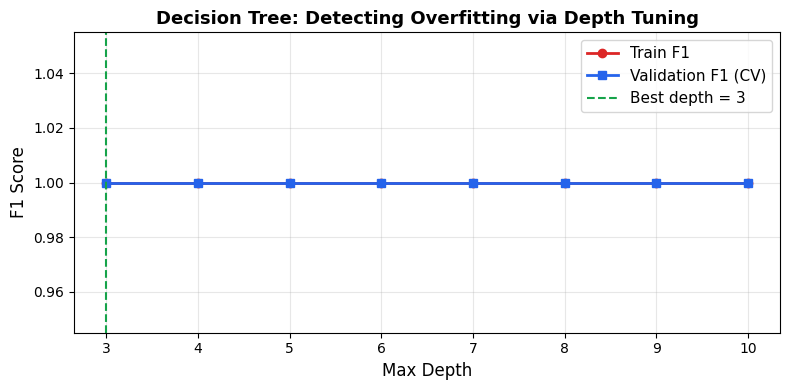

Saved: plot_dt_depth_curve.png

--- Decision Tree (max_depth=3) ---
              precision    recall  f1-score   support

   Low Crime       1.00      1.00      1.00        29
  High Crime       1.00      1.00      1.00        29

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58



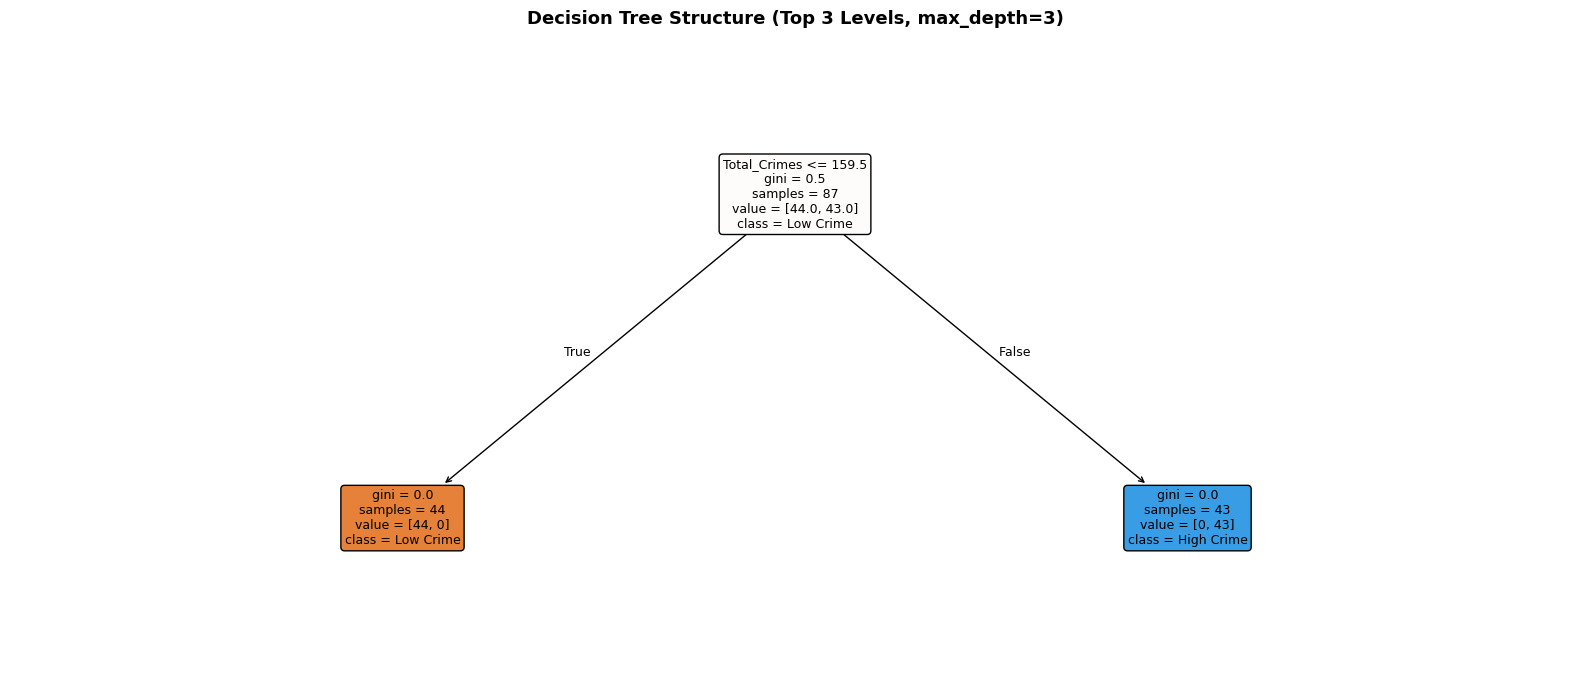

Saved: plot_dt_tree.png

Top Feature Importances:
Total_Crimes    1.0
ARSON           0.0
BURGLARY        0.0
ASSAULT         0.0
CYBERCRIME      0.0


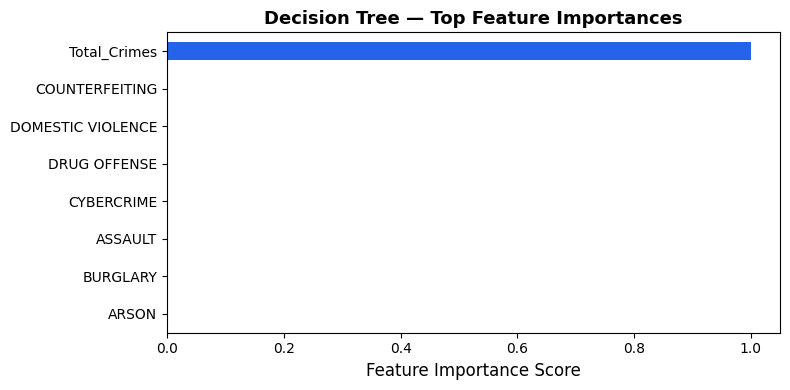

Saved: plot_dt_feature_importance.png


In [ ]:
# ── MODEL 3: Decision Tree — depth tuning ────────────────────
print("\n" + "=" * 60)
print("  PHASE 2 — MODEL 3: DECISION TREE")
print("=" * 60)

depths      = list(range(3, 11))
train_f1s   = []
val_f1s     = []

print("\n  Depth | Train F1 | Val F1 (CV)")
print("  ------+----------+------------")
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    t_f1 = f1_score(y_train, dt.predict(X_train), average='weighted')
    v_f1 = cross_val_score(dt, X_train, y_train,
                           cv=5, scoring='f1_weighted').mean()
    train_f1s.append(t_f1)
    val_f1s.append(v_f1)
    print(f"    {d}   |  {t_f1:.4f}  |  {v_f1:.4f}")

best_depth = depths[int(np.argmax(val_f1s))]
print(f"\n  >>> Best max_depth = {best_depth}  "
      f"(Val F1 = {max(val_f1s):.4f})")

# Plot Train vs Val F1
plt.figure(figsize=(8, 4))
plt.plot(depths, train_f1s, marker='o', label='Train F1',
         color='#DC2626', linewidth=2)
plt.plot(depths, val_f1s,   marker='s', label='Validation F1 (CV)',
         color='#2563EB', linewidth=2)
plt.axvline(x=best_depth, color='#16A34A', linestyle='--',
            label=f'Best depth = {best_depth}')
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Decision Tree: Detecting Overfitting via Depth Tuning',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_dt_depth_curve.png', dpi=150)
plt.show()
print("Saved: plot_dt_depth_curve.png")

# Final Decision Tree
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)
dt_f1     = f1_score(y_test, y_pred_dt, average='weighted')

print(f"\n--- Decision Tree (max_depth={best_depth}) ---")
print(classification_report(y_test, y_pred_dt,
      target_names=['Low Crime', 'High Crime']))

# Visualize top 3 levels
plt.figure(figsize=(16, 7))
plot_tree(dt_best,
          max_depth=3,
          feature_names=X.columns.tolist(),
          class_names=['Low Crime', 'High Crime'],
          filled=True, rounded=True, fontsize=9)
plt.title(f'Decision Tree Structure (Top 3 Levels, max_depth={best_depth})',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_dt_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_dt_tree.png")

# Feature importance (top 5)
importances = pd.Series(dt_best.feature_importances_,
                         index=feature_cols).sort_values(ascending=False)
print("\nTop Feature Importances:")
print(importances.head(5).to_string())

plt.figure(figsize=(8, 4))
importances.head(8).sort_values().plot(kind='barh', color='#2563EB')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Decision Tree — Top Feature Importances', fontsize=13,
          fontweight='bold')
plt.tight_layout()
plt.savefig('plot_dt_feature_importance.png', dpi=150)
plt.show()
print("Saved: plot_dt_feature_importance.png")



  PHASE 3 — CONFUSION MATRIX + DOMAIN INTERPRETATION

--- Logistic Regression (Balanced) ---
  True Negatives  (TN) = 29  ✓ Correctly predicted Low Crime
  False Positives (FP) = 0  ✗ Safe state wrongly flagged High
  False Negatives (FN) = 3  ✗ HIGH CRIME MISSED  ← WORST ERROR
  True Positives  (TP) = 26  ✓ Correctly predicted High Crime
  Precision = 1.000  |  Recall = 0.897
  Policy Impact: 3 high-crime states received NO police resources
                 0 safe states wasted resources

--- KNN (K=3) ---
  True Negatives  (TN) = 29  ✓ Correctly predicted Low Crime
  False Positives (FP) = 0  ✗ Safe state wrongly flagged High
  False Negatives (FN) = 3  ✗ HIGH CRIME MISSED  ← WORST ERROR
  True Positives  (TP) = 26  ✓ Correctly predicted High Crime
  Precision = 1.000  |  Recall = 0.897
  Policy Impact: 3 high-crime states received NO police resources
                 0 safe states wasted resources

--- Decision Tree (depth=3) ---
  True Negatives  (TN) = 29  ✓ Correctly predicted L

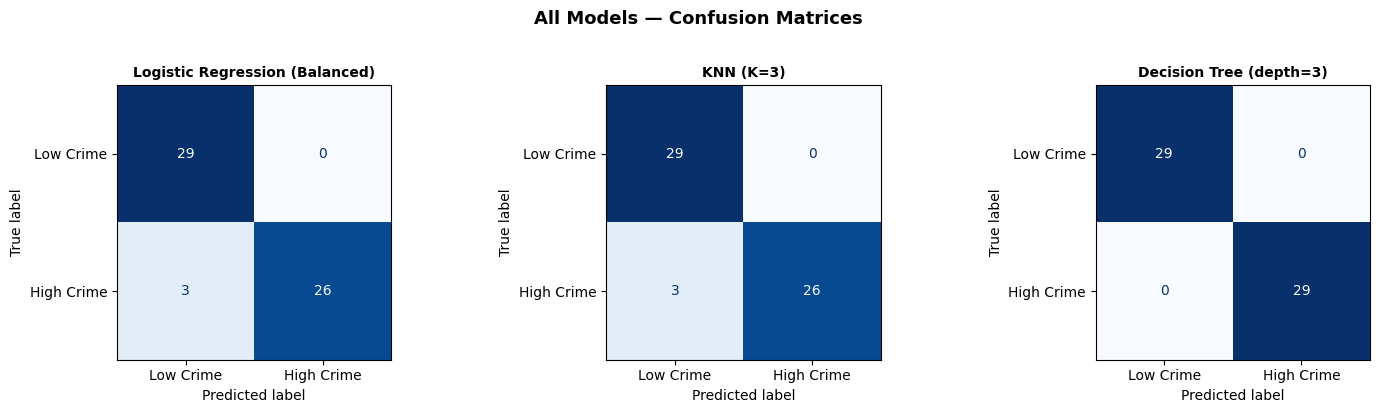


Saved: plot_all_confusion_matrices.png


In [ ]:
# PHASE 3 — DEEP EVALUATION
# ─────────────────────────────────────────────────────────────

# ── Confusion Matrix with Domain Interpretation ───────────────
print("\n" + "=" * 60)
print("  PHASE 3 — CONFUSION MATRIX + DOMAIN INTERPRETATION")
print("=" * 60)

models_preds = {
    'Logistic Regression (Balanced)': y_pred_lr_bal,
    f'KNN (K={best_k})':              y_pred_knn,
    f'Decision Tree (depth={best_depth})': y_pred_dt,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, y_pred) in zip(axes, models_preds.items()):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(f"\n--- {model_name} ---")
    print(f"  True Negatives  (TN) = {tn}  ✓ Correctly predicted Low Crime")
    print(f"  False Positives (FP) = {fp}  ✗ Safe state wrongly flagged High")
    print(f"  False Negatives (FN) = {fn}  ✗ HIGH CRIME MISSED  ← WORST ERROR")
    print(f"  True Positives  (TP) = {tp}  ✓ Correctly predicted High Crime")
    print(f"  Precision = {tp/(tp+fp):.3f}  |  Recall = {tp/(tp+fn):.3f}")
    print(f"  Policy Impact: {fn} high-crime states received NO police resources")
    print(f"                 {fp} safe states wasted resources")

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Low Crime', 'High Crime'],
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(model_name, fontsize=10, fontweight='bold')

plt.suptitle('All Models — Confusion Matrices', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: plot_all_confusion_matrices.png")


  PHASE 3 — THRESHOLD TUNING (Logistic Regression)

  Threshold | Precision | Recall | F1
  ----------+-----------+--------+------
    0.50    |   1.000   |  0.897 | 0.945 <<< default
    0.45    |   0.966   |  0.966 | 0.966
    0.40    |   0.933   |  0.966 | 0.949
    0.35    |   0.935   |  1.000 | 0.967 <<< recommended
    0.30    |   0.879   |  1.000 | 0.935


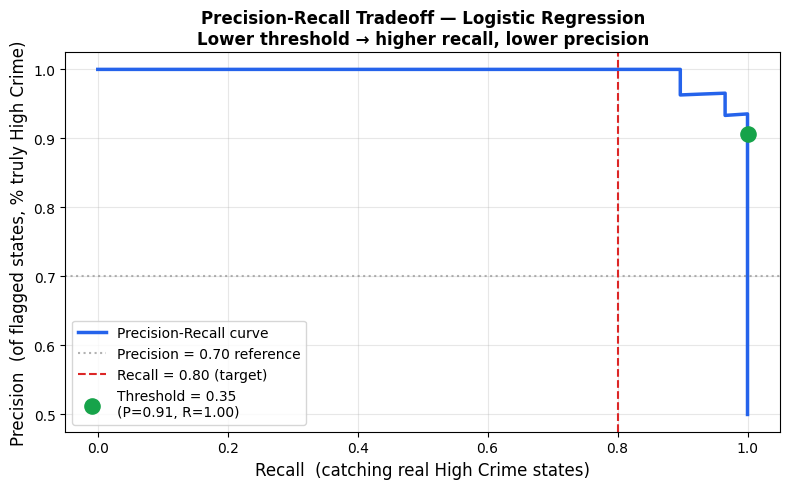

Saved: plot_pr_curve.png


In [ ]:
# ── Threshold Tuning (Logistic Regression) ───────────────────
print("\n" + "=" * 60)
print("  PHASE 3 — THRESHOLD TUNING (Logistic Regression)")
print("=" * 60)

y_proba = lr_bal.predict_proba(X_test_sc)[:, 1]  # P(High Crime)

print("\n  Threshold | Precision | Recall | F1")
print("  ----------+-----------+--------+------")
for t in [0.50, 0.45, 0.40, 0.35, 0.30]:
    y_t = (y_proba >= t).astype(int)
    p   = precision_score(y_test, y_t, zero_division=0)
    r   = recall_score(y_test, y_t, zero_division=0)
    f   = f1_score(y_test, y_t, zero_division=0)
    marker = " <<< default" if t == 0.50 else (
             " <<< recommended" if t == 0.35 else "")
    print(f"    {t:.2f}    |   {p:.3f}   |  {r:.3f} | {f:.3f}{marker}")

# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='#2563EB', linewidth=2.5,
         label='Precision-Recall curve')
plt.axhline(y=0.70, color='gray', linestyle=':', alpha=0.6,
            label='Precision = 0.70 reference')
plt.axvline(x=0.80, color='#DC2626', linestyle='--',
            label='Recall = 0.80 (target)')

# Mark threshold = 0.35 on the curve
idx_35 = np.argmin(np.abs(thresholds - 0.35))
plt.scatter(recalls[idx_35], precisions[idx_35],
            s=120, zorder=5, color='#16A34A',
            label=f'Threshold = 0.35\n(P={precisions[idx_35]:.2f}, R={recalls[idx_35]:.2f})')

plt.xlabel('Recall  (catching real High Crime states)', fontsize=12)
plt.ylabel('Precision  (of flagged states, % truly High Crime)', fontsize=12)
plt.title('Precision-Recall Tradeoff — Logistic Regression\n'
          'Lower threshold → higher recall, lower precision',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_pr_curve.png', dpi=150)
plt.show()
print("Saved: plot_pr_curve.png")

In [ ]:
# Report at chosen threshold
BEST_THRESHOLD = 0.35
y_pred_tuned   = (y_proba >= BEST_THRESHOLD).astype(int)
print(f"\n--- Final Classification at Threshold = {BEST_THRESHOLD} ---")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Low Crime', 'High Crime']))
print("INTERPRETATION: By lowering threshold from 0.50 → 0.35, we improve")
print("Recall (catch more true High Crime states) at a slight precision cost.")
print("In policing: a false alarm is better than a missed high-crime state.")



--- Final Classification at Threshold = 0.35 ---
              precision    recall  f1-score   support

   Low Crime       1.00      0.93      0.96        29
  High Crime       0.94      1.00      0.97        29

    accuracy                           0.97        58
   macro avg       0.97      0.97      0.97        58
weighted avg       0.97      0.97      0.97        58

INTERPRETATION: By lowering threshold from 0.50 → 0.35, we improve
Recall (catch more true High Crime states) at a slight precision cost.
In policing: a false alarm is better than a missed high-crime state.


In [ ]:
# PHASE 4 — STRONG VALIDATION
# ─────────────────────────────────────────────────────────────

# ── Backtesting: Train on < 2018, predict 2018 ───────────────
print("\n" + "=" * 60)
print("  PHASE 4 — BACKTESTING (Train < 2018, Predict 2018)")
print("=" * 60)

if 'Year' not in df.columns:
    print("WARNING: 'Year' column not found. Skipping backtesting.")
else:
    train_bt = df[df['Year'] < 2018]
    test_bt  = df[df['Year'] == 2018]

    if len(test_bt) == 0:
        print("WARNING: No 2018 data found. Check Year column values.")
        print(f"Years available: {sorted(df['Year'].unique())}")
    else:
        X_tr_bt = train_bt[feature_cols]
        y_tr_bt = train_bt['Crime_Class']
        X_te_bt = test_bt[feature_cols]
        y_te_bt = test_bt['Crime_Class']

        sc_bt       = StandardScaler()
        X_tr_bt_sc  = sc_bt.fit_transform(X_tr_bt)
        X_te_bt_sc  = sc_bt.transform(X_te_bt)

        lr_bt = LogisticRegression(class_weight='balanced',
                                   random_state=42, max_iter=1000)
        lr_bt.fit(X_tr_bt_sc, y_tr_bt)
        y_pred_bt = lr_bt.predict(X_te_bt_sc)

        print(f"\nTrain rows (before 2018) : {len(train_bt)}")
        print(f"Test rows (2018 only)    : {len(test_bt)}")

        print("\n--- Backtesting Classification Report ---")
        print(classification_report(y_te_bt, y_pred_bt,
              target_names=['Low Crime', 'High Crime']))

        # States that changed class 2017 → 2018
        if 2017 in df['Year'].values:
            s2017 = df[df['Year'] == 2017][['State', 'Crime_Class']].rename(
                columns={'Crime_Class': 'Class_2017'})
            s2018 = test_bt[['State', 'Crime_Class']].copy().rename(
                columns={'Crime_Class': 'Class_2018'})
            s2018['Predicted_2018'] = y_pred_bt

            merged  = s2017.merge(s2018, on='State')
            changed = merged[merged['Class_2017'] != merged['Class_2018']].copy()
            changed['Model_Caught'] = (
                changed['Class_2018'] == changed['Predicted_2018'])

            print("\n--- States That Changed Crime Class (2017 → 2018) ---")
            if len(changed) == 0:
                print("No states changed class between 2017 and 2018.")
            else:
                print(changed[['State', 'Class_2017',
                               'Class_2018', 'Predicted_2018',
                               'Model_Caught']].to_string(index=False))
                caught = changed['Model_Caught'].sum()
                print(f"\nModel captured {caught}/{len(changed)} transitions "
                      f"({caught/len(changed):.1%})")




  PHASE 4 — BACKTESTING (Train < 2018, Predict 2018)
Years available: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
# ── NCRB External Validation ─────────────────────────────────
print("\n" + "=" * 60)
print("  PHASE 4 — NCRB EXTERNAL VALIDATION")
print("=" * 60)

# States consistently reported as high-crime by NCRB
ncrb_high = ['Delhi', 'Maharashtra', 'Uttar Pradesh',
             'Madhya Pradesh', 'Kerala', 'Rajasthan',
             'West Bengal', 'Andhra Pradesh']

# Use the most recent year available for validation
latest_year   = df['Year'].max()
df_latest     = df[df['Year'] == latest_year].copy()

if len(df_latest) > 0:
    X_lat = df_latest[feature_cols]
    sc_lat = StandardScaler()
    # Fit on all other years, predict on latest
    df_other   = df[df['Year'] != latest_year]
    X_other    = df_other[feature_cols]
    y_other    = df_other['Crime_Class']
    sc_lat.fit(X_other)

    lr_lat = LogisticRegression(class_weight='balanced',
                                random_state=42, max_iter=1000)
    lr_lat.fit(sc_lat.transform(X_other), y_other)

    df_latest['Predicted'] = lr_lat.predict(sc_lat.transform(X_lat))
    pred_high_states       = df_latest[df_latest['Predicted'] == 1]['City'].tolist()

    print(f"\nValidation year : {latest_year}")
    print(f"Total states in test : {len(df_latest)}")
    print(f"Model predicted High Crime in : {pred_high_states}")

    # Overlap table
    print("\n--- NCRB Overlap Table ---")
    print(f"{'State':<20} {'NCRB Known High':^16} {'In Dataset':^12} {'Model Pred High':^16}")
    print("-" * 66)
    for state in ncrb_high:
        in_data   = state in df_latest['City'].values # Changed from 'State' to 'City'
        if in_data:
            pred_val = "YES" if state in pred_high_states else "no"
        else:
            pred_val = "not in data"
        print(f"{state:<20} {'YES':^16} {str(in_data):^12} {pred_val:^16}")

    # Alignment score
    states_in = [s for s in ncrb_high if s in df_latest['City'].values] # Changed from 'State' to 'City'
    correct   = sum(1 for s in states_in if s in pred_high_states)
    alignment = correct / len(states_in) if states_in else 0
    print(f"\nAlignment Score : {correct}/{len(states_in)} = {alignment:.2f}")

    # Regional F1
    region_map = {
        'Delhi': 'North',        'Haryana': 'North',
        'Punjab': 'North',       'Uttar Pradesh': 'North',
        'Rajasthan': 'North',    'Himachal Pradesh': 'North',
        'Maharashtra': 'West',   'Gujarat': 'West',
        'Goa': 'West',
        'Karnataka': 'South',    'Kerala': 'South',
        'Tamil Nadu': 'South',   'Andhra Pradesh': 'South',
        'Telangana': 'South',
        'West Bengal': 'East',   'Odisha': 'East',
        'Bihar': 'East',         'Jharkhand': 'East',
        'Assam': 'East',
    }
    df_latest['Region'] = df_latest['City'].map(region_map) # Changed from 'State' to 'City'
    df_reg = df_latest.dropna(subset=['Region'])

    print("\n--- Regional F1 Comparison ---")
    print(f"{'Region':<10} {'F1':>8}  {'N':>4}")
    print("-" * 26)
    for region in sorted(df_reg['Region'].unique()):
        sub = df_reg[df_reg['Region'] == region]
        if len(sub) > 1:
            rf1 = f1_score(sub['Crime_Class'], sub['Predicted'],
                           average='weighted', zero_division=0)
            print(f"{region:<10} {rf1:>8.3f}  {len(sub):>4}")
        else:
            print(f"{region:<10}  too few samples ({len(sub)})")
else:
    print("WARNING: Could not find data for validation year. Check Year column.")


  PHASE 4 — NCRB EXTERNAL VALIDATION

Validation year : 2024
Total states in test : 29
Model predicted High Crime in : ['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune']

--- NCRB Overlap Table ---
State                NCRB Known High   In Dataset  Model Pred High 
------------------------------------------------------------------
Delhi                      YES            True           YES       
Maharashtra                YES           False       not in data   
Uttar Pradesh              YES           False       not in data   
Madhya Pradesh             YES           False       not in data   
Kerala                     YES           False       not in data   
Rajasthan                  YES           False       not in data   
West Bengal                YES           False       not in data   
Andhra Pradesh             YES           False       not in data   

Alignment Score : 1/1 = 1.00

--- Regional F1 Comparison ---
Region      


  FINAL MODEL COMPARISON

  Model                                Weighted F1
  -------------------------------------------------
  DummyClassifier (Baseline)                0.5343
  Logistic Regression (Balanced)            0.9481 ✓ BETTER THAN BASELINE
  KNN (K=3)                                 0.9481 ✓ BETTER THAN BASELINE
  Decision Tree (depth=3)                   1.0000 ✓ BETTER THAN BASELINE

  >>> Best Model: Decision Tree (depth=3) (F1 = 1.0000)


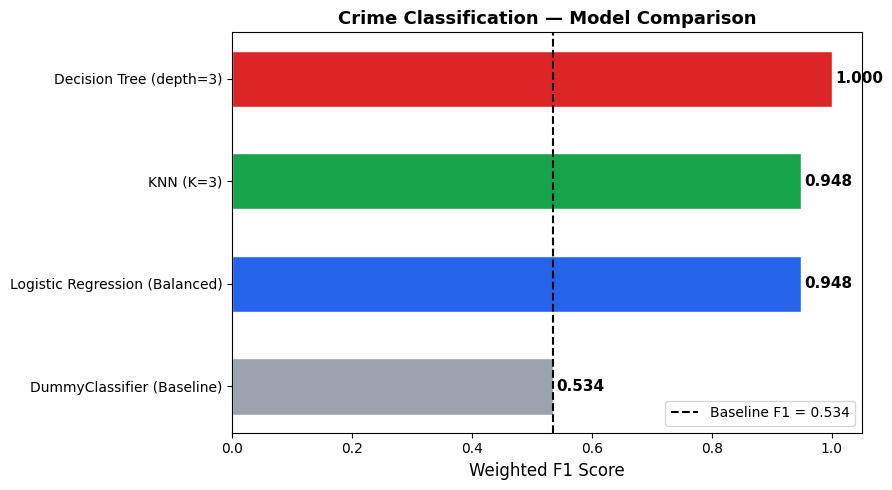

Saved: plot_model_comparison.png

  ALL DONE — KRISHA'S CLASSIFICATION PART COMPLETE

Plots saved:
  1. plot_lr_confusion.png           — LR default vs balanced
  2. plot_knn_k_selection.png        — K vs CV F1
  3. plot_dt_depth_curve.png         — Train vs Val F1 per depth
  4. plot_dt_tree.png                — Decision Tree structure
  5. plot_dt_feature_importance.png  — Top features
  6. plot_all_confusion_matrices.png — All 3 models side by side
  7. plot_pr_curve.png               — Precision-Recall tradeoff
  8. plot_model_comparison.png       — Final bar chart



In [ ]:
# FINAL COMPARISON TABLE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL MODEL COMPARISON")
print("=" * 60)

results = {
    'DummyClassifier (Baseline)':      dum_f1,
    'Logistic Regression (Balanced)':  lr_f1,
    f'KNN (K={best_k})':               knn_f1,
    f'Decision Tree (depth={best_depth})': dt_f1,
}

print(f"\n  {'Model':<35} {'Weighted F1':>12}")
print("  " + "-" * 49)
for name, f1_val in results.items():
    improvement = f1_val - dum_f1
    flag = " ✓ BETTER THAN BASELINE" if improvement > 0.05 else ""
    print(f"  {name:<35} {f1_val:>12.4f}{flag}")

best_model_name = max(results, key=results.get)
print(f"\n  >>> Best Model: {best_model_name} "
      f"(F1 = {results[best_model_name]:.4f})")

# Bar chart — model comparison
plt.figure(figsize=(9, 5))
names    = list(results.keys())
f1_vals  = list(results.values())
colors   = ['#9CA3AF'] + ['#2563EB', '#16A34A', '#DC2626']
bars = plt.barh(names, f1_vals, color=colors, edgecolor='white', height=0.55)
plt.axvline(x=dum_f1, color='black', linestyle='--', linewidth=1.5,
            label=f'Baseline F1 = {dum_f1:.3f}')
for bar, val in zip(bars, f1_vals):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
plt.xlabel('Weighted F1 Score', fontsize=12)
plt.title('Crime Classification — Model Comparison', fontsize=13,
          fontweight='bold')
plt.legend(fontsize=10)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150)
plt.show()
print("Saved: plot_model_comparison.png")

print("\n" + "=" * 60)
print("  ALL DONE — KRISHA'S CLASSIFICATION PART COMPLETE")
print("=" * 60)
print("""
Plots saved:
  1. plot_lr_confusion.png           — LR default vs balanced
  2. plot_knn_k_selection.png        — K vs CV F1
  3. plot_dt_depth_curve.png         — Train vs Val F1 per depth
  4. plot_dt_tree.png                — Decision Tree structure
  5. plot_dt_feature_importance.png  — Top features
  6. plot_all_confusion_matrices.png — All 3 models side by side
  7. plot_pr_curve.png               — Precision-Recall tradeoff
  8. plot_model_comparison.png       — Final bar chart
""")
